### Phase 1 — Exploratory Data Analysis (EDA)
#### IEEE-CIS Fraud Detection Dataset

In [1]:
###  import  the  libararies    
import  pandas  as  pd  
import  numpy  as  np  
import  matplotlib.pyplot  as  plt  
import  seaborn  as  sns    
import  missingno  as  msn   
import  os    
  

In [17]:
# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', '{:.4f}'.format)

In [3]:
###  for    the seaborn  styles  
plt.style.use('seaborn-v0_8')
   

###  load  the  data  sets  

In [6]:
DATA_PATH =   "../data/raw/"   

   

# Load transaction and identity tables
print("Loading transaction table...")
train_transaction = pd.read_csv(DATA_PATH + "train_transaction.csv")

print("Loading identity table...")
train_identity = pd.read_csv(DATA_PATH + "train_identity.csv")


###  check   the   loaded  data sets  


print("successfully   loaded  !!!  ")
print(f"\n✅ train_transaction shape : {train_transaction.shape}")
print(f"✅ train_identity shape    : {train_identity.shape}")  



Loading transaction table...
Loading identity table...
successfully   loaded  !!!  

✅ train_transaction shape : (590540, 394)
✅ train_identity shape    : (144233, 41)


### Merge Transaction + Identity Tables

In [7]:
###  Merge on TransactionID (left join — not all transactions have identity info)
df = train_transaction.merge(train_identity, on='TransactionID', how='left')

print(f"✅ Merged dataframe shape: {df.shape}")
print(f"   Rows    : {df.shape[0]:,}")
print(f"   Columns : {df.shape[1]:,}")

✅ Merged dataframe shape: (590540, 434)
   Rows    : 590,540
   Columns : 434


###  basic   informations    

In [9]:
df.shape

(590540, 434)

In [10]:
###  take    the descriptionn  of  the  data sets    
df.describe()   

,TransactionID,isFraud,TransactionDT,TransactionAmt,card1,card2,card3,card5,addr1,addr2,dist1,dist2,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,...,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_13,id_14,id_17,id_18,id_19,id_20,id_21,id_22,id_24,id_25,id_26,id_32
count,590540.0000,590540.0000,590540.0000,590540.0000,590540.0000,581607.0000,588975.0000,586281.0000,524834.0000,524834.0000,238269.0000,37627.0000,590540.0000,590540.0000,590540.0000,590540.0000,590540.0000,590540.0000,590540.0000,590540.0000,590540.0000,590540.0000,590540.0000,590540.0000,590540.0000,590540.0000,589271.0000,309743.0000,327662.0000,421618.0000,280699.0000,73187.0000,38917.0000,74926.0000,74926.0000,514518.0000,311253.0000,64717.0000,61952.0000,62187.0000,...,82351.0000,82351.0000,82351.0000,82351.0000,82351.0000,82351.0000,82351.0000,82351.0000,82351.0000,82351.0000,82351.0000,82351.0000,82351.0000,82351.0000,82351.0000,82351.0000,82351.0000,144233.0000,140872.0000,66324.0000,66324.0000,136865.0000,136865.0000,5155.0000,5155.0000,74926.0000,74926.0000,140978.0000,127320.0000,80044.0000,139369.0000,45113.0000,139318.0000,139261.0000,5159.0000,5169.0000,4747.0000,5132.0000,5163.0000,77586.0000
mean,3282269.5000,0.0350,7372311.3101,135.0272,9898.7347,362.5555,153.1949,199.2789,290.7338,86.8006,118.5022,231.8554,14.0925,15.2697,0.0056,4.0922,5.5715,9.0711,2.8485,5.1446,4.4802,5.2403,10.2415,4.0762,32.5399,8.2952,94.3476,169.5632,28.3433,140.0024,42.3360,69.8057,41.6389,146.0581,0.5611,123.9821,146.6215,54.0375,17.9013,57.7244,...,13.1038,9.1846,0.0585,0.8510,0.2966,0.3368,1.3128,0.7759,721.7419,1375.7836,1014.6228,9.8070,59.1645,28.5309,55.3524,151.1605,100.7009,-10.1705,174716.5847,0.0602,-0.0589,1.6156,-6.6987,13.2854,-38.6004,0.0910,-0.3011,99.7453,48.0531,-344.5071,189.4514,14.2373,353.1282,403.8827,368.2698,16.0027,12.8009,329.6089,149.0703,26.5086
std,170474.3583,0.1838,4617223.6465,239.1625,4901.1702,157.7932,11.3364,41.2445,101.7411,2.6906,371.8720,529.0535,133.5690,154.6689,0.1505,68.8485,25.7870,71.5085,61.7273,95.3786,16.6749,95.5814,94.3363,86.6662,129.3648,49.5443,157.6604,177.3159,62.3847,191.0968,89.0001,143.6693,99.7433,231.6638,0.3169,182.6152,186.0426,124.2746,67.6144,136.3125,...,106.7398,73.6279,0.3044,3.9503,1.3644,1.5801,8.7691,4.7280,6217.2236,11169.2757,7955.7355,243.8614,387.6295,274.5769,668.4868,1095.0344,814.9467,14.3479,159651.8169,0.5982,0.7010,5.2499,16.4911,11.3842,26.0849,0.9838,2.7894,1.1276,11.7749,93.6955,30.3754,1.5613,141.0953,152.1603,198.8470,6.8977,2.3724,97.4611,32.1020,3.7375
min,2987000.0000,0.0000,86400.0000,0.2510,1000.0000,100.0000,100.0000,100.0000,100.0000,10.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-122.0000,0.0000,-83.0000,0.0000,0.0000,0.0000,0.0000,-53.0000,-83.0000,0.0000,-193.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-100.0000,1.0000,-13.0000,-28.0000,-72.0000,-100.0000,-46.0000,-100.0000,-36.0000,-100.0000,90.0000,10.0000,-660.0000,100.0000,10.0000,100.0000,100.0000,100.0000,10.0000,11.0000,100.0000,100.0000,0.0000
25%,3134634.7500,0.0000,3027057.7500,43.3210,6019.0000,214.0000,150.0000,166.0000,204.0000,87.0000,3.0000,7.0000,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,1.0000,0.0000,26.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.9583,0.2083,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-10.0000,67992.0000,0.0000,0.0000,0.0000,-6.0000,5.0000,-48.0000,0.0000,0.0000,100.0000,49.0000,-360.0000,166.0000,13.0000,266.0000,256.0000,252.0000,14.0000,11.0000,321.0000,119.0000,24.0000
50%,3282269.5000,0.0000,7306527.5000,

In [21]:
### check  the  data  types    
## df.dtypes

In [19]:
### show  the  data sets    
df.head()  

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5000,W,13926,NaN,150.0000,discover,142.0000,credit,315.0000,87.0000,19.0000,NaN,NaN,NaN,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,2.0000,0.0000,1.0000,1.0000,14.0000,NaN,13.0000,NaN,NaN,NaN,NaN,NaN,NaN,13.0000,13.0000,NaN,NaN,NaN,0.0000,T,T,T,M2,F,T,NaN,NaN,NaN,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,117.0000,0.0000,0.0000,0.0000,0.0000,0.0000,117.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,0.0000

In [20]:
print("=" * 50)
print("DATA TYPES")
print("=" * 50)
print(df.dtypes.value_counts())
print(f"\nTotal columns : {df.shape[1]}")
print(f"Numeric cols  : {df.select_dtypes(include=np.number).shape[1]}")
print(f"Object cols   : {df.select_dtypes(include='object').shape[1]}")

DATA TYPES
float64    399
object      31
int64        4
Name: count, dtype: int64

Total columns : 434
Numeric cols  : 403
Object cols   : 31


### Target Variable — Fraud Distribution

FRAUD DISTRIBUTION
Legitimate (0) : 569,877  (96.50%)
Fraud      (1) : 20,663  (3.50%)

Imbalance ratio : 27.6:1


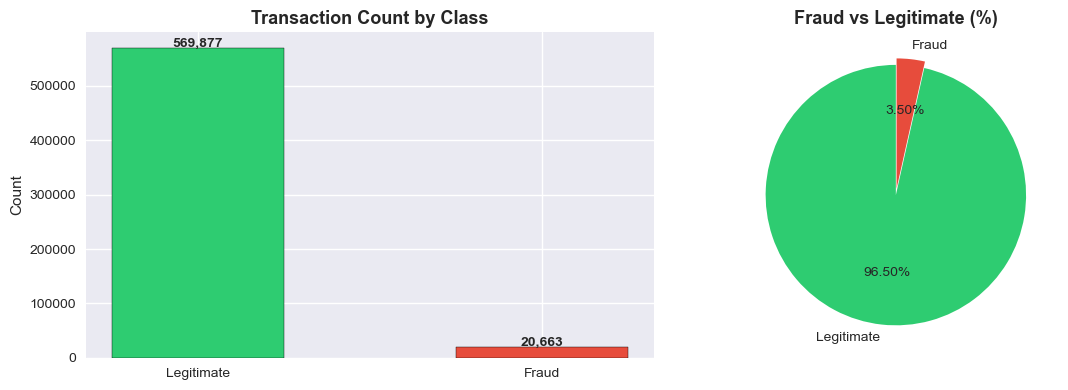

✅ Plot saved


In [22]:
fraud_counts = df['isFraud'].value_counts()
fraud_pct    = df['isFraud'].value_counts(normalize=True) * 100

print("=" * 40)
print("FRAUD DISTRIBUTION")
print("=" * 40)
print(f"Legitimate (0) : {fraud_counts[0]:,}  ({fraud_pct[0]:.2f}%)")
print(f"Fraud      (1) : {fraud_counts[1]:,}  ({fraud_pct[1]:.2f}%)")
print(f"\nImbalance ratio : {fraud_counts[0]/fraud_counts[1]:.1f}:1")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(['Legitimate', 'Fraud'], fraud_counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='black', width=0.5)
axes[0].set_title('Transaction Count by Class', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(fraud_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(fraud_counts.values, labels=['Legitimate', 'Fraud'],
            colors=['#2ecc71', '#e74c3c'], autopct='%1.2f%%',
            startangle=90, explode=(0, 0.05))
axes[1].set_title('Fraud vs Legitimate (%)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/processed/fraud_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved")

### Missing Values Analysis

In [23]:
df.isnull().mean() * 100  

TransactionID     0.0000
isFraud           0.0000
TransactionDT     0.0000
TransactionAmt    0.0000
ProductCD         0.0000
card1             0.0000
card2             1.5127
card3             0.2650
card4             0.2670
card5             0.7212
card6             0.2660
addr1            11.1264
addr2            11.1264
dist1            59.6524
dist2            93.6284
P_emaildomain    15.9949
R_emaildomain    76.7516
C1                0.0000
C2                0.0000
C3                0.0000
C4                0.0000
C5                0.0000
C6                0.0000
C7                0.0000
C8                0.0000
C9                0.0000
C10               0.0000
C11               0.0000
C12               0.0000
C13               0.0000
C14               0.0000
D1                0.2149
D2               47.5492
D3               44.5149
D4               28.6047
D5               52.4674
D6               87.6068
D7               93.4099
D8               87.3123
D9               87.3123


In [25]:
### detect  the  missing columns  
miss_cols   =  [cols    for   cols  in   df.columns   if   df[cols].isnull().sum()  >  1 ] 

In [27]:
###  find  the  percantages  of  the  missing  values    
df[miss_cols].isnull().mean()  * 100  

print("=" * 40)   

print() ###  new  line   

print(f"no  of  missing  vlues  columns  : {len(miss_cols)} ")


no  of  missing  vlues  columns  : 414 


In [28]:
# Calculate missing values
missing = pd.DataFrame({
    'missing_count'  : df.isnull().sum(),
    'missing_percent': (df.isnull().sum() / len(df)) * 100
}).sort_values('missing_percent', ascending=False)

missing = missing[missing['missing_count'] > 0]

print(f"Columns WITH missing values : {len(missing)} / {df.shape[1]}")
print(f"Columns with >50% missing   : {len(missing[missing['missing_percent'] > 50])}")
print(f"Columns with >90% missing   : {len(missing[missing['missing_percent'] > 90])}")
print("\nTop 20 columns with most missing:")
print(missing.head(20).to_string())

Columns WITH missing values : 414 / 434
Columns with >50% missing   : 214
Columns with >90% missing   : 12

Top 20 columns with most missing:
       missing_count  missing_percent
id_24         585793          99.1962
id_25         585408          99.1310
id_07         585385          99.1271
id_08         585385          99.1271
id_21         585381          99.1264
id_26         585377          99.1257
id_27         585371          99.1247
id_23         585371          99.1247
id_22         585371          99.1247
dist2         552913          93.6284
D7            551623          93.4099
id_18         545427          92.3607
D13           528588          89.5093
D14           528353          89.4695
D12           525823          89.0410
id_04         524216          88.7689
id_03         524216          88.7689
D6            517353          87.6068
id_33         517251          87.5895
id_09         515614          87.3123


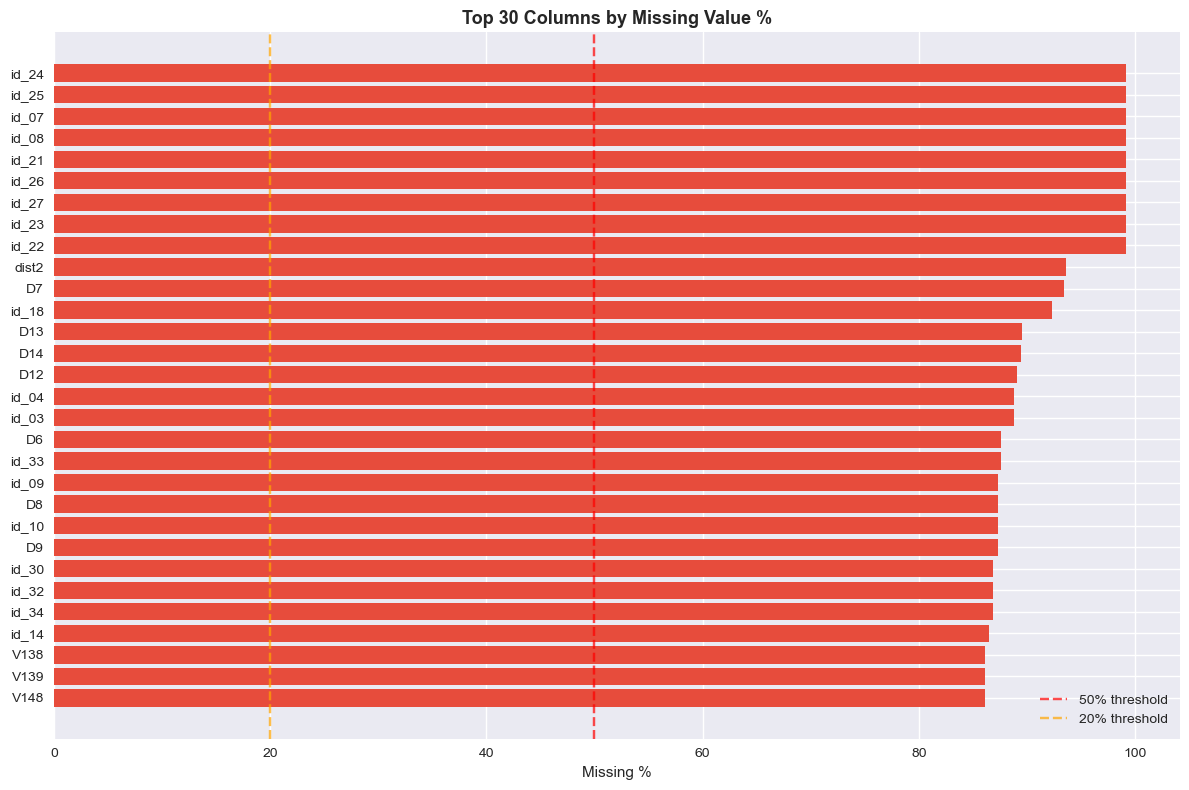

✅ Plot saved


In [29]:
# Visualise top 30 missing columns
top_missing = missing.head(30)

plt.figure(figsize=(12, 8))
bars = plt.barh(top_missing.index, top_missing['missing_percent'],
                color=['#e74c3c' if x > 50 else '#f39c12' if x > 20 else '#3498db'
                       for x in top_missing['missing_percent']])
plt.axvline(x=50, color='red', linestyle='--', alpha=0.7, label='50% threshold')
plt.axvline(x=20, color='orange', linestyle='--', alpha=0.7, label='20% threshold')
plt.xlabel('Missing %')
plt.title('Top 30 Columns by Missing Value %', fontsize=13, fontweight='bold')
plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../data/processed/missing_values.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved")

In [30]:
##3  ttake  the  obejct  data    
obj_cols  =     [cols    for  cols   in    df.columns   if      df[cols].dtypes   ==  "O"]   